# Analyse Exploratoire des Données (EDA) - Prédiction du Temps de Livraison
## Objectif
- Comprendre sa structure du dataset et son contenu
- Comprendre les variables influençant le temps de livraison (`Delivery_Time_min`)  
- Identifier les tendances et relations importantes dans le dataset

## Analyse des données
- Variables numériques : statistiques descriptives et corrélations  
- Variables catégorielles : countplots et boxplots pour étudier leur impact sur la cible  
- Distribution de la cible : histogramme et KDE pour détecter anomalies et valeurs extrêmes  

## Insights
- Variables les plus pertinentes  
- Suppression des valeurs aberrantes (outliers)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [74]:
df = pd.read_csv(r"C:\Users\khadija\Desktop\simplon project\Data-IA-Simplon-Maghreb\Brief2- Prédiction Temps de Livraison\Prédiction-Temps-Livraison.csv")

In [75]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Data cleaning 


In [79]:
def cleaning_data(df,cols_inutile= None):
    """
    Nettoie le DataFrame en effectuant les opérations suivantes :
    - Suppression des doublons
    - Suppression des colonnes inutiles
    - Conversion de 'TotalCharges' en numérique
    - Remplissage des valeurs manquantes (numériques et catégorielles)
    """
    df_cleaned = df.copy()
    
    # Remove the dupilcate row
    df_cleaned = df_cleaned.drop_duplicates()
    # Check missing value 
    df.isna().sum()
    # suprimmer les colonnes inutiles 
    if cols_inutile :
        df_cleaned = df_cleaned.drop(columns= cols_inutile, errors='ignore')
    # fill missing value for numérique variable 
    df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"] .fillna(df["Courier_Experience_yrs"] .mean())
    # fill missing value for catégoriale variable 
    catg_cols = df.select_dtypes(include='object').columns
    for col in catg_cols :
        df[col] = df[col].fillna(df[col].mode()[0]) # la valeur le plus fréquentes 
    
    
    return df_cleaned

In [83]:
df_cleaned = cleaning_data(df,cols_inutile=['Order_ID'] )
df_cleaned.head()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   object 
 2   Traffic_Level           1000 non-null   object 
 3   Time_of_Day             1000 non-null   object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [102]:
from test_Pipeline import test_dim
test_dim (df,df_cleaned)


 Test des dimensions réussi  (1000, 8)


## Analyse et visualisations 

In [82]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.870301,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,4.579381,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


### Corrélation entre des variables numériques

In [13]:
# Sélection des colonnes numériques
numer_cols = df.select_dtypes(include='number')

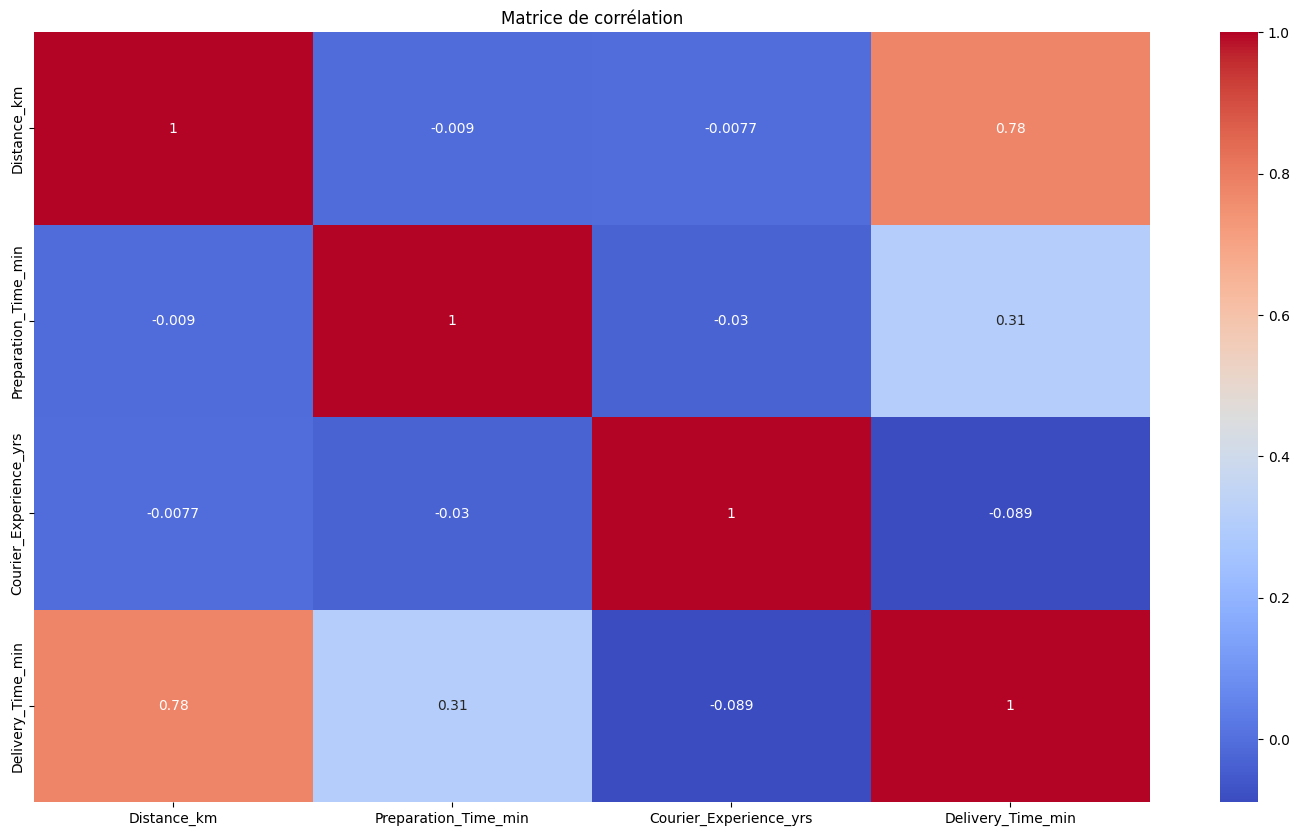

In [14]:
# Calcul de la matrice de corrélation
corr_matrix = numer_cols.corr()

plt.figure(figsize=(18,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

- La corrélation entre le temps de livraison et la distance entre le restaurant et l’adresse de livraison est de 0,78.Etant proche de 1, cela indique une forte corrélation positive.

### Distribution des variables catégorielle

In [15]:
#  Countplot pour visualiser la distribution des variables catégorielle
def plot_countplot(df, column,title=None):
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, data=df)
    plt.title(title if title else f"Répartition de {column} ")
    plt.xlabel(column)
    plt.ylabel("Nombre de counts")
    plt.show()

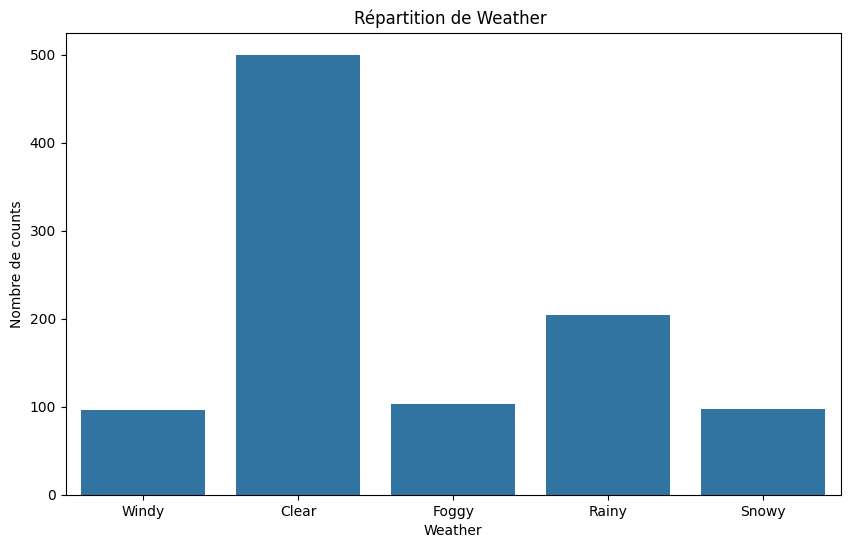

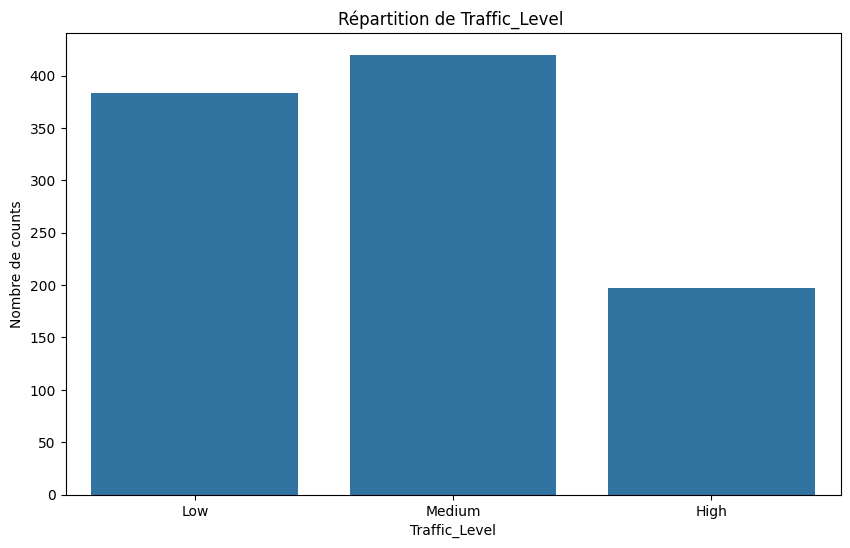

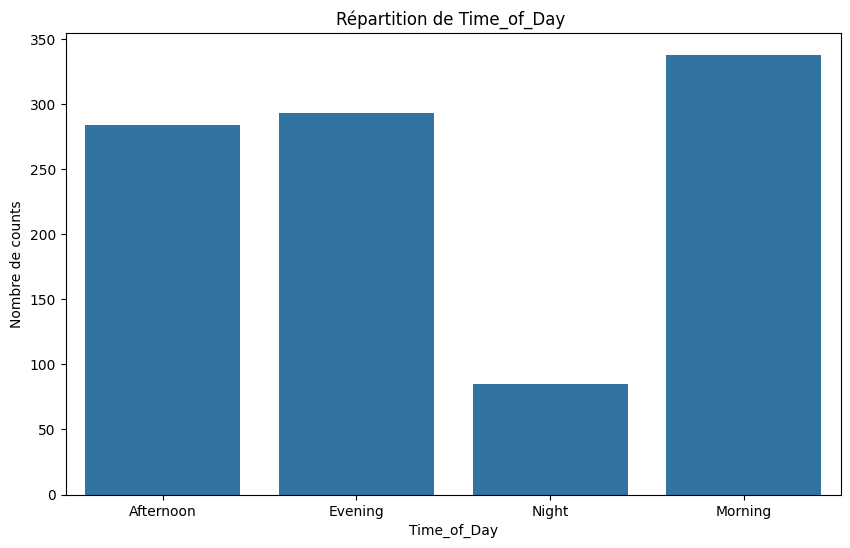

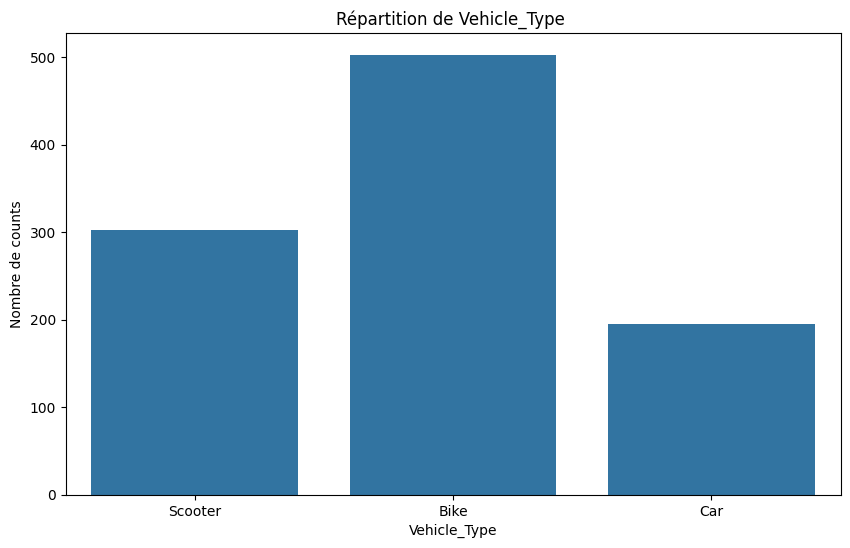

In [16]:
for col in catg_cols:
    plot_countplot(df, column=col)

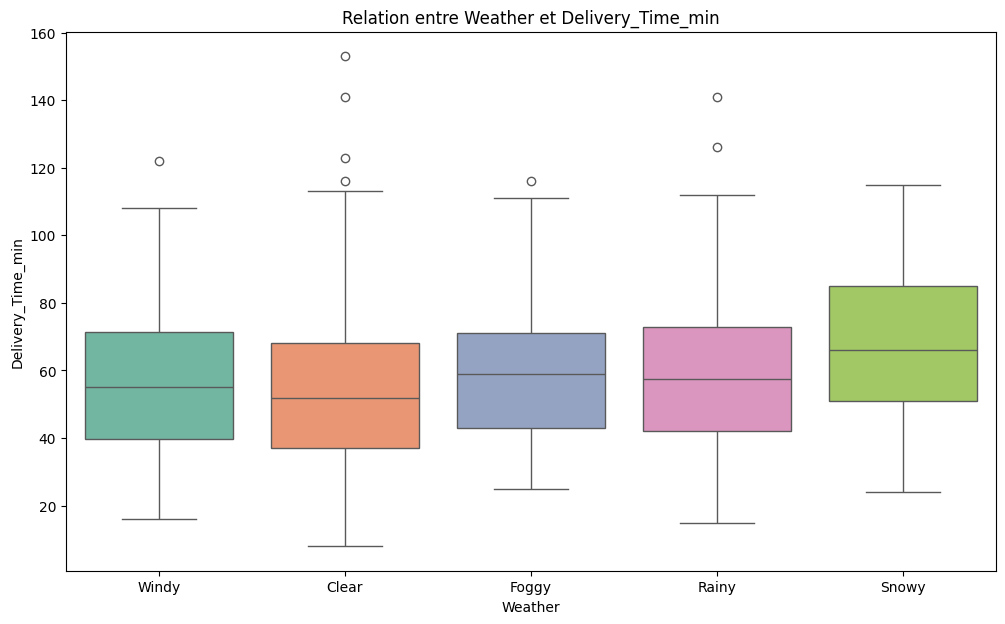

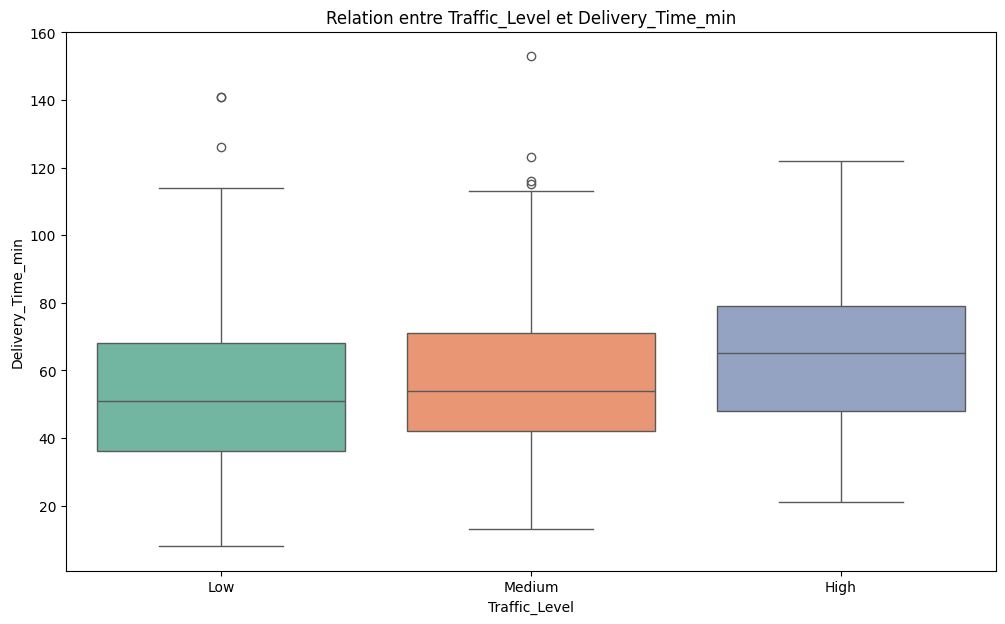

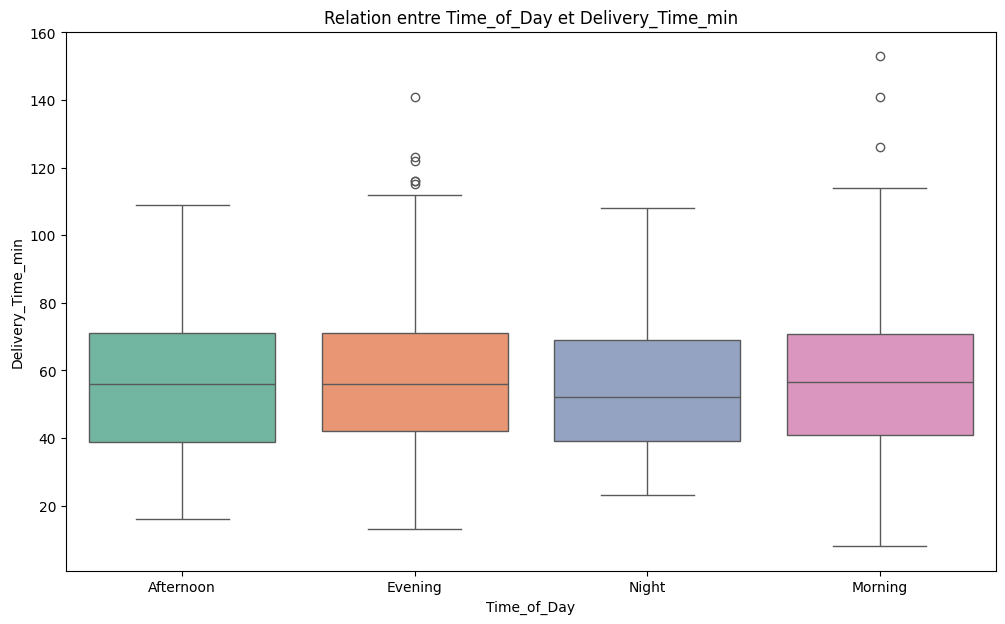

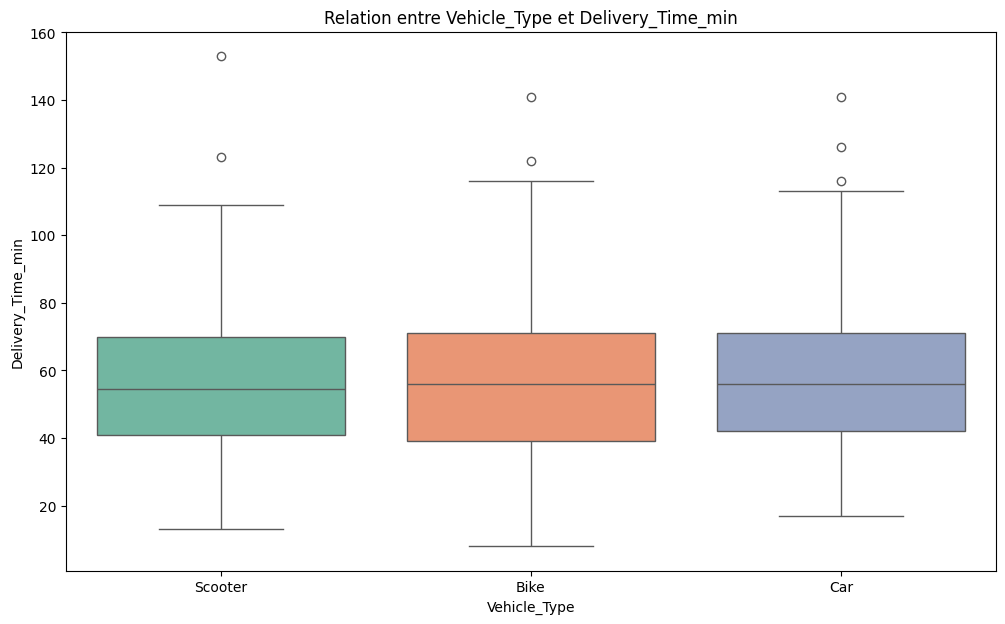

In [17]:
# Boxplots pour visualiser la relation entre la variable cible et les variables catégorielles.
for col in catg_cols : 
    plt.figure(figsize=(12, 7))
    sns.boxplot(data = df ,x= col,y ='Delivery_Time_min',hue= col, palette='Set2')
    plt.title(f'Relation entre {col} et Delivery_Time_min')
    plt.xlabel(col)
    plt.ylabel('Delivery_Time_min')
    plt.show()

D'apres les graphes On conclu que :
  - Le temps da la livraison varie selon les conditions méteorologiques 
  - Le niveau de trafic a un impact direct et significatif sur le temps de livraison.
  - Les livraisons sont plus rapides et régulières la nuit, tandis que le matin et le soir présentent plus de retards et de variabilité.
  - Le type de véhicule n’influence pas beaucoup sur le temps de livraison.

### Analyse de la distribution de la variable cible

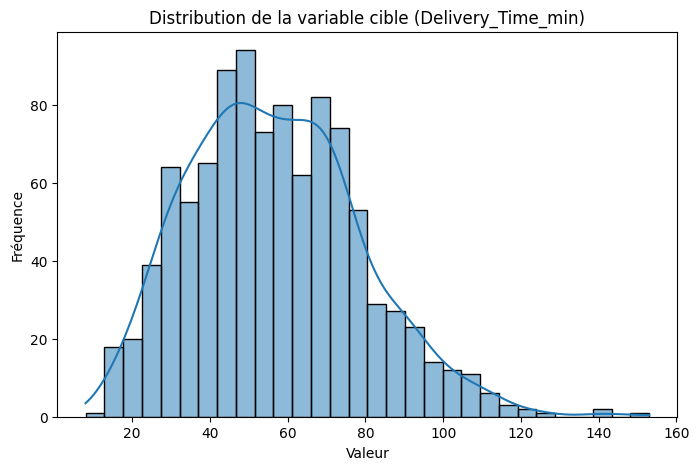

In [18]:
# Analyser la distribution de la variable cibl avec  histogramme
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title("Distribution de la variable cible (Delivery_Time_min)")
plt.xlabel("Valeur")
plt.ylabel("Fréquence")
plt.show()

- La majorité des livraisons prennent entre 30 et 70 minutes,mais parfois il y a des livraisons qui durent beaucoup plus longtemps.

# Prétraitement (StandardScaler pour numérique, OneHotEncoder pour catégoriel)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import make_scorer, mean_absolute_error ,r2_score


In [20]:
# La colonne Courier_Experience_yrs est supprimée car elle n pour l’analyse.
df = df.drop('Courier_Experience_yrs', axis=1)

## Encodage des variables catégorielles

In [21]:
# selection les variables catégoriales 

# Encodage avec get_dummies (One-Hot)
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded.head()

,Distance_km,Preparation_Time_min,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,16.42,20,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,9.52,28,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,7.44,5,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,19.03,16,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


## Normalisation des variables numériques avec Standardscaler 

In [22]:
# selection les variables numériques 
numer_cols = ['Distance_km','Preparation_Time_min']
df_scaled = df_encoded.copy()
# scaler
scaler = StandardScaler()

df_scaled[numer_cols ] = scaler.fit_transform(df_scaled[numer_cols])
df_scaled.head()

,Distance_km,Preparation_Time_min,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,-0.374085,-0.691853,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,1.117008,0.419111,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,-0.094835,1.530076,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,-0.460144,-1.663947,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,1.575401,-0.136371,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


In [23]:
# Séparation features et la cible
X = df_scaled.drop(columns=['Delivery_Time_min'])
y = df_scaled['Delivery_Time_min']

# Sélection de features (SelectKBest)

In [24]:

selector = SelectKBest(score_func=f_regression, k=5)
X_selected = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]
print("Colonnes sélectionnées :", selected_columns)

Colonnes sélectionnées : Index(['Distance_km', 'Preparation_Time_min', 'Weather_Clear', 'Weather_Snowy',
       'Traffic_Level_High'],
      dtype='object')


# Modélisation avec GridSearchCV

In [25]:
param_grid_rf = { 
    'n_estimators': [100, 300, 400],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5,10],
    'min_samples_leaf': [1, 2,7],
}

In [26]:
param_grid_svr = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.1, 0.2, 0.5]
}

In [27]:
# Créer le scorer MAE (plus bas = mieux)
scoring  = {'MAE':  make_scorer(mean_absolute_error,greater_is_better=False),
             'R2' : make_scorer(r2_score) 
             }





# GridSearch pour RandomForestRegressor
GridSearch_rf = GridSearchCV (
    estimator= RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring = scoring,
    refit='MAE',
    n_jobs=-1
)

In [28]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
GridSearch_rf.fit(X_train, y_train)
# Résultats
print("Meilleurs paramètres Random Forest :", GridSearch_rf.best_params_)
print("Meilleur MAE Random Forest :", GridSearch_rf.best_score_)


Meilleurs paramètres Random Forest : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}
Meilleur MAE Random Forest : -8.13608055264777


In [30]:
best_model = GridSearch_rf.best_estimator_

y_pred = best_model.predict(X_test)

In [31]:
mae_rf = mean_absolute_error(y_test, y_pred)
print("MAE Random Forest :", mae_rf)

MAE Random Forest : 6.789281544631764


In [32]:
# GridSearch pour SVR
grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring=scoring,
    refit= "MAE",
    n_jobs=1
)
grid_svr.fit(X_train, y_train)
print("Meilleurs paramètres SVR :", grid_svr.best_params_)
print("Meilleur MAE SVR :", grid_svr.best_score_)

Meilleurs paramètres SVR : {'C': 1, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
Meilleur MAE SVR : -6.9078539776882675


In [33]:
best_model_svr = grid_svr.best_estimator_

y_pred = best_model_svr.predict(X_test)

In [34]:
mae_svr = mean_absolute_error(y_test, y_pred)
print("MAE Random Forest :", mae_svr)

MAE Random Forest : 6.152614176806204


# Pipeline 

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [36]:
num_cols=['Distance_km','Preparation_Time_min']
cat_cols=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']

In [37]:
X.head()

,Distance_km,Preparation_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,-0.374085,-0.691853,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,1.117008,0.419111,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,-0.094835,1.530076,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,-0.460144,-1.663947,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,1.575401,-0.136371,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


In [56]:
preprocessor  = ColumnTransformer(
     transformers= [ 
         ('num',StandardScaler(),num_cols),
         ('cat', OneHotEncoder(handle_unknown='ignore'),cat_cols)
     ] )

In [57]:
pipe_rf = Pipeline(
    steps=[
        ('preprocessor' , preprocessor),
        ('select', SelectKBest(score_func=f_regression)),
        ('regressor',RandomForestRegressor(random_state=42))
        ]
        )

In [58]:
param_pipe_rf = { 
    'select__k': [5, 10, 'all'],
    'regressor__n_estimators': [100, 300, 400],
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [2, 5,10],
    'regressor__min_samples_leaf': [1, 2,7],
}

In [59]:
scoring = {
    "MAE" : make_scorer(mean_absolute_error),
    "R2" : make_scorer(r2_score)
}

In [60]:
grid_search_pipe_rf = GridSearchCV(
    estimator = pipe_rf,
    param_grid = param_pipe_rf,
    scoring = scoring,
    refit = "MAE",
    cv = 5,
    n_jobs = -1,
    verbose=2


)
 

In [61]:
pipe_rf.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'preprocessor', 'select', 'regressor', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cat', 'preprocessor__num__copy', 'preprocessor__num__with_mean', 'preprocessor__num__with_std', 'preprocessor__cat__categories', 'preprocessor__cat__drop', 'preprocessor__cat__dtype', 'preprocessor__cat__feature_name_combiner', 'preprocessor__cat__handle_unknown', 'preprocessor__cat__max_categories', 'preprocessor__cat__min_frequency', 'preprocessor__cat__sparse_output', 'select__k', 'select__score_func', 'regressor__bootstrap', 'regressor__ccp_alpha', 'regressor__criterion', 'regressor__max_depth', 'regressor__max_features', 'regressor__max_leaf_nodes', 'regressor__max_samples', 'regressor__min_impurity_decrease',

In [62]:
# Séparation features et la cible
X = df.drop(columns=['Delivery_Time_min'])
y = df['Delivery_Time_min']

In [63]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [64]:
grid_search_pipe_rf.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type'])])),
                                       ('select',
                                        SelectKBest(score_func=<function f_regression at 0x00000177D02FC860>)),
                                       ('regress...
             n_jobs=-1,
             param_grid={'regressor__max_depth': [None, 5, 10],
                         'regressor__min_samples_leaf': [1, 2, 7],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [100, 300, 400],
                         'select__k': [5, 10, 'all']},
             refit='MAE',
             scoring={'MAE': make_scorer(mean_absolute_error, response_method='predict'),
                      'R2': make_scorer(r2_score, response_method='predict')},
             verbose=2)

In [65]:
print("Best parameters:", grid_search_pipe.best_params_)
print("Best score:", grid_search_pipe.best_score_)

Best parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100, 'select__k': 5}
Best score: 8.503840952380953


In [66]:
best_pipeline = grid_search_pipe.best_estimator_
y_pred = best_pipeline.predict(X_test)



In [67]:

MAE_rf = mean_absolute_error(y_test, y_pred)
print(f"MAE (Mean Absolute Error) random Forest: {MAE_rf:.4f}")

MAE (Mean Absolute Error) random Forest: 7.6770


In [68]:
pipe_svr = Pipeline(
    steps=[
        ('preprocessor' , preprocessor),
        ('select', SelectKBest(score_func=f_regression)),
        ('regressor',SVR())
        ]
        )

In [69]:
param_pipe_svr = {
    'select__k': [5, 10, 'all'],
    'regressor__kernel': ['rbf', 'linear'],
    'regressor__C': [0.1, 1, 10],
    'regressor__gamma': ['scale', 'auto'],
    'regressor__epsilon': [0.1, 0.2, 0.5]
}


In [70]:
grid_search_pipe_svr = GridSearchCV(
    estimator = pipe_svr,
    param_grid = param_pipe_svr,
    scoring = scoring,
    refit = "MAE",
    cv = 5,
    n_jobs = -1,
    verbose=2


)

In [71]:
grid_search_pipe_svr.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type'])])),
                                       ('select',
                                        SelectKBest(score_func=<function f_regression at 0x00000177D02FC860>)),
                                       ('regressor', SVR())]),
             n_jobs=-1,
             param_grid={'regressor__C': [0.1, 1, 10],
                         'regressor__epsilon': [0.1, 0.2, 0.5],
                         'regressor__gamma': ['scale', 'auto'],
                         'regressor__kernel': ['rbf', 'linear'],
                         'select__k': [5, 10, 'all']},
             refit='MAE',
             scoring={'MAE': make_scorer(mean_absolute_error, response_method='predict'),
                      'R2': make_scorer(r2_score, response_method='predict')},
             verbose=2)

In [72]:
print("Best parameters:", grid_search_pipe.best_params_)
print("Best score:", grid_search_pipe.best_score_)

Best parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100, 'select__k': 5}
Best score: 8.503840952380953
